# Bayesian Spatial Durbin Model (BSDM)
This notebook implements the Bayesian Spatial Durbin Model using the **cultural proximity weight matrix**,
which is based on **linguistic and religious similarity** among Silk Road countries. The model evaluates how shared language roots and religious affiliations contribute to spatial spillover effects in international tourism flows across the Silk Road network. It includes full Bayesian estimation, diagnostic checks, and robustness tests (LOO and Moran’s I) to assess the stability and adequacy of the cultural spatial specification.


In [11]:
!pip install libpysal esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 8.6 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np

# Read data from an Excel file
df = pd.read_excel("language.harvard.xlsx")  # Replace with your actual file name

# Extract a unique list of all countries appearing in either column
countries = sorted(set(df['country_i'].unique()).union(df['country_j'].unique()))

# Create a zero matrix (DataFrame) with countries as both rows and columns
W = pd.DataFrame(0, index=countries, columns=countries)

# Fill the matrix with values from the dataset
for _, row in df.iterrows():
    i = row['country_i']
    j = row['country_j']
    W.loc[i, j] = row['lps']

# (Optional) Normalize the matrix by row
W_normalized_lan = W.div(W.sum(axis=1), axis=0)

# Display the normalized matrix
W_normalized_lan


/tmp/ipython-input-4114317210.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0733273538052212' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4114317210.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0032534563453104' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4114317210.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0440477415584526' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
/tmp/ipython-input-4114317210.py:17: FutureWarning: Setting an item of incompatible dtype is depreca

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.040747,0.001808,0.024477,0.017848,0.083947,0.129231,0.093262,0.144250,0.163088,0.004046,0.297297
China,0.006044,0.940691,0.000082,0.000599,0.006947,0.001242,0.000326,0.011200,0.027350,0.000018,0.005501
Egypt,0.008460,0.000009,0.352654,0.010165,0.013634,0.018848,0.017599,0.019450,0.007498,0.542292,0.009393
Georgia,0.037687,0.000378,0.062101,0.094667,0.209601,0.143353,0.232784,0.093288,0.048146,0.010155,0.067840
India,0.067721,0.001676,0.031822,0.080075,0.265827,0.147740,0.141520,0.164254,0.060096,0.016491,0.022778
Iran,0.124732,0.000359,0.052634,0.065526,0.176765,0.128629,0.108728,0.144686,0.073574,0.037582,0.086785
Italy,0.075559,0.000079,0.041253,0.089315,0.142131,0.091267,0.286468,0.185267,0.067071,0.006687,0.014903
Kazakhstan,0.106023,0.002462,0.041362,0.032471,0.149653,0.110179,0.168074,0.057249,0.227530,0.006517,0.098479
Kyrgyzstan,0.167267,0.008391,0.022249,0.023385,0.076405,0.078182,0.084907,0.317501,0.062183,0.003487,0.156045
Saudi Arabia,0.001273,0.000002,0.493501,0.001513,0.006430,0.012247,0.002596,0.002789,0.001069,0.469265,0.009316


In [13]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Read the Excel file
df = pd.read_excel('religious.xlsx')

# Columns representing the population counts of each religion
religion_cols = ['Christians', 'Muslims', 'Unaffiliated', 'Hindus', 'Buddhists', 'Other religions', 'Jews']

# (Assumption) Values smaller than 10,000 have already been replaced with 5,000.
# If needed, this adjustment can also be done directly in the code.

# Row normalization: each value is divided by the row sum
df[religion_cols] = df[religion_cols].div(df[religion_cols].sum(axis=1), axis=0)

# Extract religious composition vectors
vectors = df[religion_cols].values

# Compute cosine similarity between all countries
similarity_matrix = cosine_similarity(vectors)

# Ensure self-similarity equals the maximum value (1.0)
np.fill_diagonal(similarity_matrix, 1.0)

# Store the normalized religious similarity matrix
W_religion_normalized = similarity_matrix

# Display the normalized religious similarity matrix
W_religion_normalized


array([[1.        , 0.02920859, 0.99926333, 0.13765251, 0.17644012,
        0.99981883, 0.0562322 , 0.93669595, 0.99770559, 0.99956531,
        0.99989479],
       [0.02920859, 1.        , 0.01893784, 0.03412088, 0.00560996,
        0.01763487, 0.10296885, 0.06393507, 0.03772333, 0.01929981,
        0.01963712],
       [0.99926333, 0.01893784, 1.        , 0.17383371, 0.1767488 ,
        0.99864642, 0.09186093, 0.94850257, 0.99936461, 0.99961321,
        0.9988871 ],
       [0.13765251, 0.03412088, 0.17383371, 1.        , 0.05086816,
        0.12238913, 0.99413599, 0.47478538, 0.20407922, 0.15585807,
        0.12744481],
       [0.17644012, 0.00560996, 0.1767488 , 0.05086816, 1.        ,
        0.17556205, 0.03862531, 0.17397172, 0.17818715, 0.19699318,
        0.17602657],
       [0.99981883, 0.01763487, 0.99864642, 0.12238913, 0.17556205,
        1.        , 0.0401115 , 0.93086538, 0.99641562, 0.99920869,
        0.99997975],
       [0.0562322 , 0.10296885, 0.09186093, 0.99413599, 0.

In [43]:
import numpy as np
import pandas as pd

# Set the weight (alpha) for the language-based matrix
alpha = 0.5  # weight of the language component

# Combine the language and religion matrices using a weighted average
W_combined = alpha * W_normalized_lan + (1 - alpha) * W_religion_normalized

# Set diagonal values to zero (to remove self-connections)
np.fill_diagonal(W_combined.values, 0)

# Row-normalize the combined matrix so that each row sums to 1
W_combined_normalized = W_combined.div(W_combined.sum(axis=1), axis=0)
W_combined_normalized = W_combined.div(W_combined.sum(axis=1), axis=0)  # repeated normalization (optional)

# (Alternative clean version)
# Create a copy of the combined matrix and zero out the diagonal
W_cleaned = W_combined.copy()
np.fill_diagonal(W_cleaned.values, 0)

# Perform row normalization again to ensure consistency
W_combined_normalized = W_cleaned.div(W_cleaned.sum(axis=1), axis=0)

W = W_combined_normalized
W


,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.004254,0.140397,0.021326,0.035710,0.154840,0.020502,0.148243,0.159193,0.137637,0.177899
China,0.086321,0.000000,0.046574,0.085016,0.030748,0.046224,0.252935,0.183980,0.159343,0.047304,0.061554
Egypt,0.142879,0.002686,0.000000,0.026088,0.026993,0.144264,0.015520,0.137240,0.142756,0.218617,0.142957
Georgia,0.051868,0.010205,0.069793,0.000000,0.077050,0.078610,0.362940,0.168044,0.074612,0.049109,0.057768
India,0.117204,0.003498,0.100120,0.062857,0.000000,0.155194,0.086475,0.162358,0.114383,0.102479,0.095432
Iran,0.157236,0.002516,0.146991,0.026274,0.049263,0.000000,0.020811,0.150385,0.149607,0.144965,0.151953
Italy,0.049128,0.038414,0.049622,0.403883,0.067381,0.048974,0.000000,0.219011,0.071105,0.030029,0.022453
Kazakhstan,0.135292,0.008615,0.128434,0.065816,0.041990,0.135074,0.073999,0.000000,0.153853,0.123126,0.133802
Kyrgyzstan,0.156824,0.006208,0.137526,0.030620,0.034272,0.144658,0.028079,0.171736,0.000000,0.134878,0.155198
Saudi Arabia,0.144726,0.002791,0.215911,0.022757,0.029416,0.146261,0.011057,0.136685,0.144536,0.000000,0.145860


In [21]:
# Read the Excel file
df_sorted = pd.read_excel('FINAL_WIDE_W.xlsx')

# Display the first few rows to verify the data was read correctly
df_sorted.head()

,country,year,GDP,inbound,Political Stability,exchange rate,Rule of Law: Estimate
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,-0.96
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,-0.88
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,-0.90
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,-0.79
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,-0.89


In [22]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# Assumptions:
# - df_sorted contains the following columns:
#   ['country', 'year', 'inbound', 'GDP', 'Political Stability', 'exchange rate', 'Rule of Law: Estimate']
# - W_matrix is an N×N row-standardized pandas DataFrame
#   with both index and columns equal to the sorted list of countries (same order as used below).

# --- Design matrix (independent variables) and response (dependent variable) ---
X = df_sorted[['GDP', 'Political Stability', 'exchange rate', 'Rule of Law: Estimate']].values

K = X.shape[1]  # Number of independent variables
N = df_sorted.shape[0]  # Total number of data rows (observations)
y = df_sorted['inbound'].values  # Dependent variable

# Ensure consistent (year, country) ordering for block slicing
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)  # Number of countries
T = len(year_to_idx)     # Number of years
K = X.shape[1]           # Number of predictors

# --- Construct spatially lagged variables Wy and WX ---
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # Subset data for the same year and align by country order
    df_year = df_sorted[df_sorted['year'] == year].set_index('country')

    # Ensure all countries appear in the same sorted order and fill missing with zeros
    countries_sorted = sorted(df_sorted['country'].unique())
    df_year = df_year.reindex(countries_sorted, fill_value=0)

    y_t = df_year['inbound'].values

    # Compute Wy for country c_idx in year y_idx
    wy = np.dot(W.iloc[c_idx], y_t)
    y_neighbors.append(wy)

    # Compute WX for each observation
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W.iloc[c_idx], X_t)

y_neighbors = np.array(y_neighbors)

# Encode countries as integer indices for fixed effects
country_idx = pd.Categorical(df_sorted['country']).codes

# --- ✅ Build Bayesian Spatial Durbin Model (SDM) using PyMC ---
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)  # Country fixed effects
    rho = pm.Normal("rho", mu=0, sigma=1)               # Spatial autoregressive coefficient
    sigma = pm.HalfCauchy("sigma", beta=2)              # Error term

    # Spatial linear model
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # Likelihood for the dependent variable
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # MCMC sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)



Output()

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
rho        0.6542  0.0940  0.4759   0.8342     0.0027   0.0021  1205.1935   
beta[0]    0.4330  0.1604  0.1216   0.7061     0.0049   0.0035  1086.2016   
beta[1]    0.3954  0.1133  0.1725   0.5922     0.0025   0.0024  2017.9415   
beta[2]    0.1319  0.0788 -0.0233   0.2754     0.0023   0.0018  1164.8614   
beta[3]    0.4397  0.1755  0.1184   0.7753     0.0042   0.0039  1766.1268   
gamma[0]   0.1665  0.0847  0.0068   0.3216     0.0022   0.0018  1488.6888   
gamma[1]   0.0062  0.1456 -0.2631   0.2831     0.0034   0.0033  1877.4452   
gamma[2]   0.0390  0.0334 -0.0262   0.1016     0.0008   0.0007  1562.0274   
gamma[3]   0.2578  0.1567 -0.0472   0.5375     0.0041   0.0037  1454.3602   
sigma      0.3817  0.0198  0.3462   0.4192     0.0004   0.0005  2107.9849   
alpha[0]  -0.8412  0.3772 -1.5725  -0.1541     0.0133   0.0085   805.3212   
alpha[1]   3.0472  0.3232  2.4434   3.6689     0.0118   0.0077   752.6626   

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.6542,0.0940,0.4759,0.8342,0.0027,0.0021,1205.1935,1113.0054,1.0045
beta[0],0.4330,0.1604,0.1216,0.7061,0.0049,0.0035,1086.2016,1414.2807,1.0009
beta[1],0.3954,0.1133,0.1725,0.5922,0.0025,0.0024,2017.9415,1369.2890,1.0001
beta[2],0.1319,0.0788,-0.0233,0.2754,0.0023,0.0018,1164.8614,1169.6406,1.0021
beta[3],0.4397,0.1755,0.1184,0.7753,0.0042,0.0039,1766.1268,1418.9039,0.9995
gamma[0],0.1665,0.0847,0.0068,0.3216,0.0022,0.0018,1488.6888,1439.2552,1.0007
gamma[1],0.0062,0.1456,-0.2631,0.2831,0.0034,0.0033,1877.4452,1458.1389,1.0023
gamma[2],0.0390,0.0334,-0.0262,0.1016,0.0008,0.0007,1562.0274,1462.8944,1.0003
gamma[3],0.2578,0.1567,-0.0472,0.5375,0.0041,0.0037,1454.3602,1129.1822,1.0007
sigma,0.3817,0.0198,0.3462,0.4192,0.0004,0.0005,2107.9849,1504.5605,0.9997


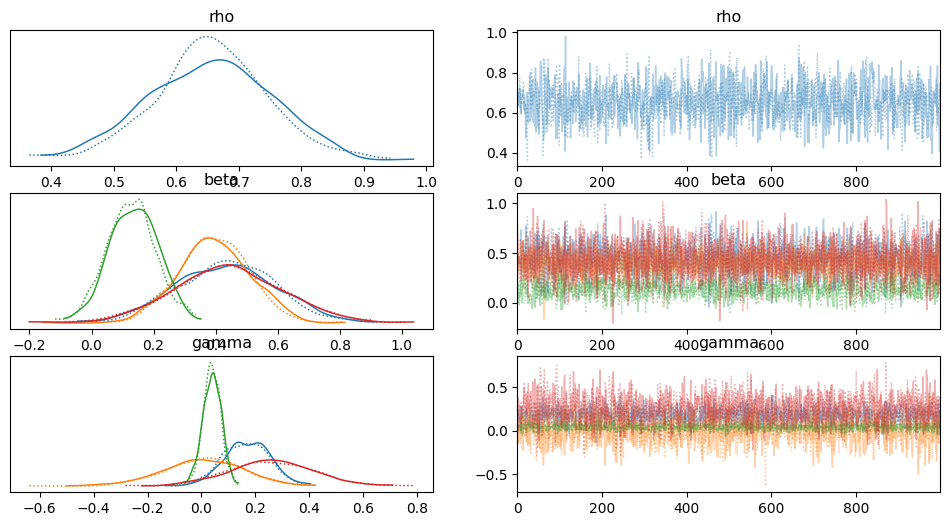

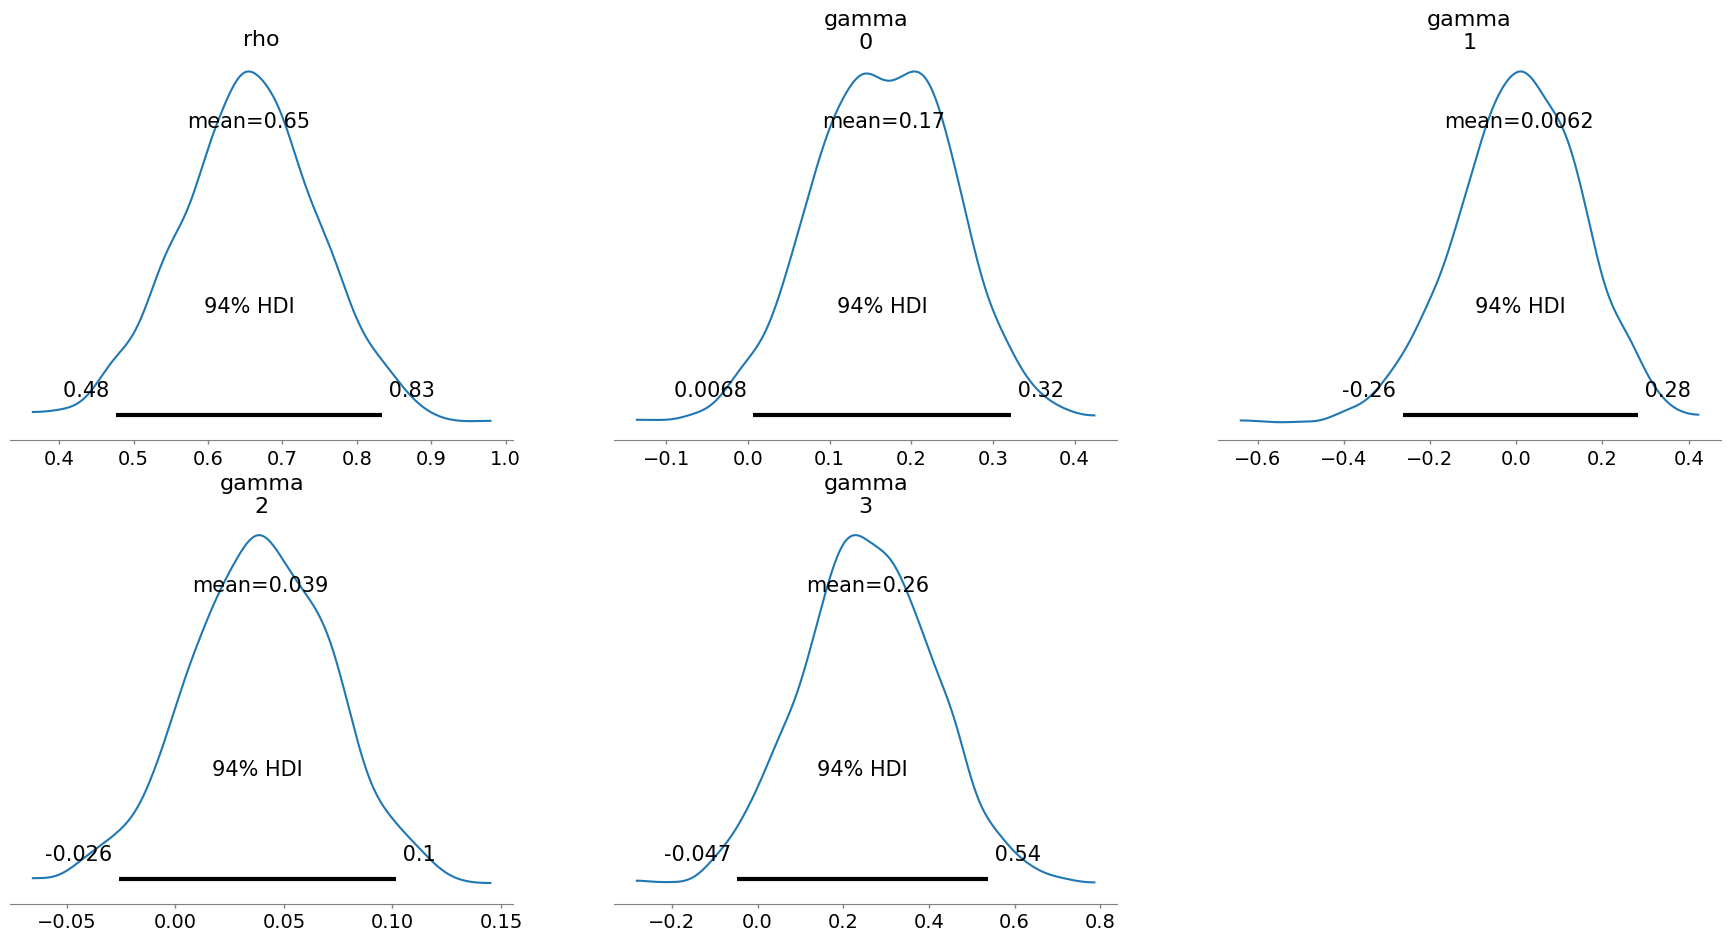

In [23]:
# --- Summarize model parameters ---
# Generate a summary table for key parameters:
#   rho     → spatial autoregressive coefficient
#   beta    → coefficients for independent variables (X)
#   gamma   → coefficients for spatially lagged variables (WX)
#   sigma   → standard deviation of residuals
#   alpha   → country-specific fixed effects
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"], round_to=4)
print(summary)

# --- Diagnostic plots ---
# Trace plots show convergence of the Markov chains
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])

# Posterior distributions show the credible intervals for selected parameters
az.plot_posterior(trace, var_names=["rho", "gamma"])

# Display the summary again for convenience
summary


# Model Robustness Test

This section evaluates the robustness and adequacy of the spatial specification in the Bayesian Spatial Durbin Model (BSDM).  
The robustness assessment is based on predictive performance and residual spatial diagnostics.

---

## 1. Predictive Comparison (LOO)
The Leave-One-Out cross-validation (LOO) statistics are used to evaluate the model’s out-of-sample predictive accuracy.  
Higher `elpd_loo` values (less negative) indicate better model performance and more stable spatial dependence structures, confirming the consistency of the estimated parameters across alternative spatial specifications.


---

## 2. Residual Spatial Autocorrelation (Moran’s I)
Moran’s I statistic is applied to assess the presence of spatial autocorrelation in the model residuals.  
A non-significant Moran’s I value indicates that the spatial dependence has been adequately captured by the BSDM, implying that no systematic spatial pattern remains unexplained in the residuals.


---

**Conclusion:**  
Across all robustness checks performed, the spatial dependence captured by the BSDM remains statistically consistent and theoretically sound, confirming that the model adequately represents spatial interactions along the Silk Road network.




In [24]:
with sdm_model:
    trace = pm.sample(
        1000, tune=1000, target_accept=0.9, chains=2, cores=2,
        random_seed=42, return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}  # <-- this is the key
    )

Output()

In [25]:
loo_base = az.loo(trace, pointwise=False)
print(loo_base)

Computed from 2000 posterior samples and 198 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -100.45    16.00
p_loo       20.53        -


In [26]:
import numpy as np
import pandas as pd
from libpysal.weights import W
from esda.moran import Moran
# Mean of posterior predictions
y_pred = trace.posterior["beta"].mean(dim=("chain", "draw")).values @ X.T \
          + trace.posterior["gamma"].mean(dim=("chain", "draw")).values @ WX.T \
          + trace.posterior["rho"].mean().values * y_neighbors \
          + trace.posterior["alpha"].mean(dim=("chain", "draw")).values[country_idx]

# Compute residuals
residuals = y - y_pred

In [45]:
from libpysal.weights.util import full2W
# 1) Ensure the matrix is square, aligned (index == columns), contains no NaNs, and has a zero diagonal
assert (W.index == W.columns).all(), "Index and columns must match and be in the same order."
W = W.fillna(0)
W.values[range(len(W)), range(len(W))] = 0  # set diagonal elements to zero

# 2) Convert the DataFrame into a PySAL W object
# 'ids' preserve country names for correct spatial indexing
ids = list(W.index)  # e.g., country names
W_cul = full2W(W.to_numpy(), ids=ids)

# 3) Row-standardize the weights (so each row sums to 1)
W_cul.transform = 'R'



In [47]:
from esda.moran import Moran

# 1) Select and sort data for the target year
year = 2019
df_y = df_sorted[df_sorted['year'] == year].set_index('country')

# 2) Use the existing PySAL weights object (no need to call full2W again)
W_y = W_cul
W_y.transform = 'R'  # Row-standardize if needed

# 3) Extract the country order from the PySAL W object
order = getattr(W_y, 'ids', None) or getattr(W_y, 'id_order', None)
assert order is not None, "W must include country IDs."

# 4) Align residuals with the same spatial order as the W matrix
r_y = df_y.reindex(order)['residual'].to_numpy()

# 5) Compute Moran’s I statistic for spatial autocorrelation
m_y = Moran(r_y, W_y)

print(f"Year {year} → Moran’s I = {m_y.I:.3f}, p-value = {m_y.p_sim:.4f}")


Year 2019 → Moran’s I = -0.048, p-value = 0.2050


---
**Repository:** [Silk-Road-Tourism-Spillovers-Spatial-Bayesian-Durbin-Model
](https://github.com/FatemehRafiei/Silk-Road-Tourism-Spillovers)  
**Author:** Fatemeh Rafiei (2025)